# Demo pipeline: QC → PETH → Population → Coding Direction

This notebook demonstrates the analysis pipeline for a single example session:
- load session pickle
- run QC and produce cluster summaries and PNGs
- compute per-cluster PETHs aligned to `Change_ON`
- assemble a population tensor (trials × bins × units)
- compute a time-resolved coding direction (Hit vs Miss) and project trials
- compare Hit vs False Alarm (baseline) as an additional control

Cells are ordered so you can re-run top-to-bottom after a kernel restart.

In [1]:
# 1) Standard imports and repo path
import sys
from pathlib import Path
import os

# Try to find the repository root: prefer cwd, else walk parents looking for 'src' and 'data'.
start = Path.cwd()
repo_root = None
p = start.resolve()
for _ in range(8):
    if (p / 'src').is_dir() and (p / 'data').is_dir():
        repo_root = p
        break
    p = p.parent
# Fallback to a common absolute path used in this workspace
if repo_root is None:
    candidate = Path(r'e:/python_analysis/git_repos/vis_detect_analysis_Sep2025')
    if candidate.exists():
        repo_root = candidate
    else:
        repo_root = start

# Add repo root to sys.path so `import src.*` works
sys.path.insert(0, str(repo_root.resolve()))
print('repo_root set to:', repo_root)

import numpy as np
import matplotlib.pyplot as plt
# For interactive notebooks you can enable inline plotting; if running headless remove the next line
# %matplotlib inline

# Standard analysis defaults
bin_size = 0.02
window = (-0.5, 1.0)
baseline_window = (-0.5, 0.0)
print('Defaults: bin_size=', bin_size, 'window=', window)


repo_root set to: E:\python_analysis\git_repos\vis_detect_analysis_Sep2025
Defaults: bin_size= 0.02 window= (-0.5, 1.0)


## Requirements

Recommended packages (conda):
```bash
conda create -n vis_detect python=3.10 -y
conda activate vis_detect
conda install -y numpy scipy pandas matplotlib h5py pytest -c conda-forge
```
Or with pip:
```bash
pip install numpy scipy pandas matplotlib h5py pytest
```


In [2]:
# 2) Load example session
from src.session_io import load_session
pkl_path = repo_root / 'data' / 'BG_031_250425.pkl'
print('Loading:', pkl_path)
session = load_session(str(pkl_path))
print('Session summary:')
print('  trials:', len(getattr(session, 'trials', [])))
print('  clusters:', len(getattr(session, 'clusters', [])))
print('  good_cluster_ids:', len(getattr(session, 'good_cluster_ids', [])))

Loading: E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\data\BG_031_250425.pkl
Session summary:
  trials: 568
  clusters: 611
  good_cluster_ids: 320


## 3) Run QC (writes JSON + PNGs into a local tmp folder)

Generates simple QC plots and a summary CSV in `tmp_demo_qc/`.

QC artifacts written to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\tmp_demo_qc


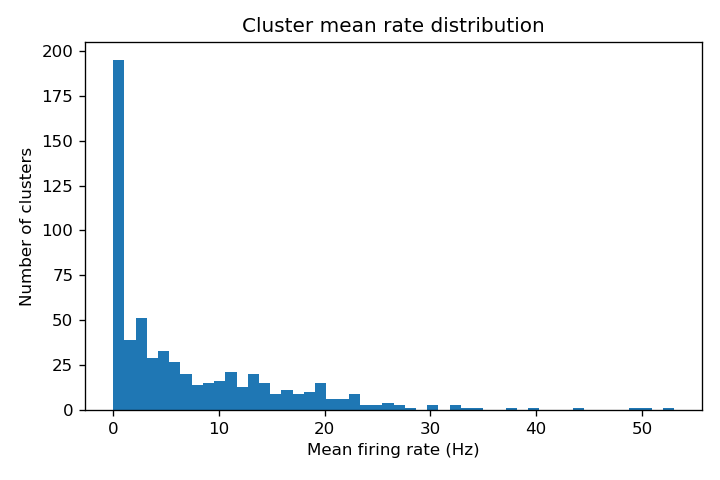

In [3]:
out_qc_dir = repo_root / 'tmp_demo_qc'
out_qc_dir.mkdir(exist_ok=True)
from src.qc import run_qc
run_qc(session, str(out_qc_dir))
print('QC artifacts written to', out_qc_dir)
# Optionally display a PNG if available
files = list(out_qc_dir.glob('*.png'))
if files:
    from IPython.display import Image, display
    display(Image(str(files[0])))

## 4) Compute PETHs aligned to `Change_ON` and (optionally) cache them

We compute per-cluster PETHs with a compact bin size for the demo.

In [4]:
from src.align import compute_peth_for_session
event_name = 'Change_ON'
print('Computing PETHs...')
peths = compute_peth_for_session(session, event_name, window=window, bin_size=bin_size)
print('Computed PETHs for', len(peths), 'clusters')

Computing PETHs...
Computed PETHs for 320 clusters


## 5) Build population matrix (trials × bins × units)

Only clusters with full trial matrices are included so shapes stay consistent.

In [5]:
# Build a sorted list of cluster IDs that have full trial matrices
cluster_ids = sorted([cid for cid, info in peths.items() if info['trials_matrix'].shape[0] > 0])
if len(cluster_ids) == 0:
    raise RuntimeError('No clusters with trial matrices found in PETHs')
example = peths[cluster_ids[0]]
n_trials, n_bins = example['trials_matrix'].shape
print('Using', len(cluster_ids), 'clusters -> pop shape will be (trials={}, bins={}, units={})'.format(n_trials, n_bins, len(cluster_ids)))
pop_list = []
use_ids = []
for cid in cluster_ids:
    mat = peths[cid]['trials_matrix']
    if mat.shape[0] == n_trials and mat.shape[1] == n_bins:
        pop_list.append(mat)
        use_ids.append(cid)
pop = np.stack(pop_list, axis=2)  # trials x bins x units
print('Built pop with shape', pop.shape)
# Save use_ids for reference
use_ids = list(use_ids)
print('Using %d clusters' % len(use_ids))

Using 320 clusters -> pop shape will be (trials=569, bins=75, units=320)
Built pop with shape (569, 75, 320)
Using 320 clusters


## 6) Compute time-resolved coding direction (Hit vs Miss)

Create condition masks and compute a cross-validated, time-resolved CD.

In [7]:
# Build condition mask: Hit vs Miss
trial_outcomes = [getattr(t, 'trialoutcome', None) for t in session.trials]
cond_hit = np.array([o == 'Hit' for o in trial_outcomes])
cond_miss = np.array([o == 'Miss' for o in trial_outcomes])
print('n Hit, n Miss =', cond_hit.sum(), cond_miss.sum())
from src.coding_direction import time_resolved_cd
res = time_resolved_cd(pop, cond_hit, method='shrinkage', reg=1.0, n_splits=5, n_permutations=50, random_state=0)
proj = res['proj']  # trials x bins
effect = res.get('effect', None)
print('Computed time-resolved CD and projections')

n Hit, n Miss = 154 221


IndexError: boolean index did not match indexed array along axis 0; size of axis is 569 but size of corresponding boolean axis is 568

## 7) Plot average projected trajectories for Hit vs Miss

Plot mean ± SEM trajectories using the cross-validated projections.

In [17]:
# Helper: plot projections for two groups (mean ± SEM).
import numpy as np
import matplotlib.pyplot as plt
def plot_projection_compare(proj, mask_a, mask_b, bins, labels=('A','B'), colors=('C0','C1'), ax=None, title=None):
    """Plot mean ± SEM for two groups from a projections matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
    else:
        fig = ax.figure
    # Ensure boolean masks are numpy arrays and align with proj rows
    mask_a = np.asarray(mask_a)
    mask_b = np.asarray(mask_b)
    # Select rows
    A = proj[mask_a]
    B = proj[mask_b]
    if A.size == 0 or B.size == 0:
        ax.text(0.5, 0.5, 'Insufficient trials for one or both groups', ha='center', va='center')
        return fig, ax
    mean_a = A.mean(axis=0)
    mean_b = B.mean(axis=0)
    sem_a = A.std(axis=0) / np.sqrt(max(1, A.shape[0]))
    sem_b = B.std(axis=0) / np.sqrt(max(1, B.shape[0]))
    ax.fill_between(bins, mean_a - sem_a, mean_a + sem_a, color=colors[0], alpha=0.2)
    ax.fill_between(bins, mean_b - sem_b, mean_b + sem_b, color=colors[1], alpha=0.2)
    ax.plot(bins, mean_a, label=labels[0], color=colors[0])
    ax.plot(bins, mean_b, label=labels[1], color=colors[1])
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Time (s) relative to Change_ON')
    ax.set_ylabel('Projection onto CD (a.u.)')
    ax.legend()
    if title is not None:
        ax.set_title(title)
    fig.tight_layout()
    return fig, ax


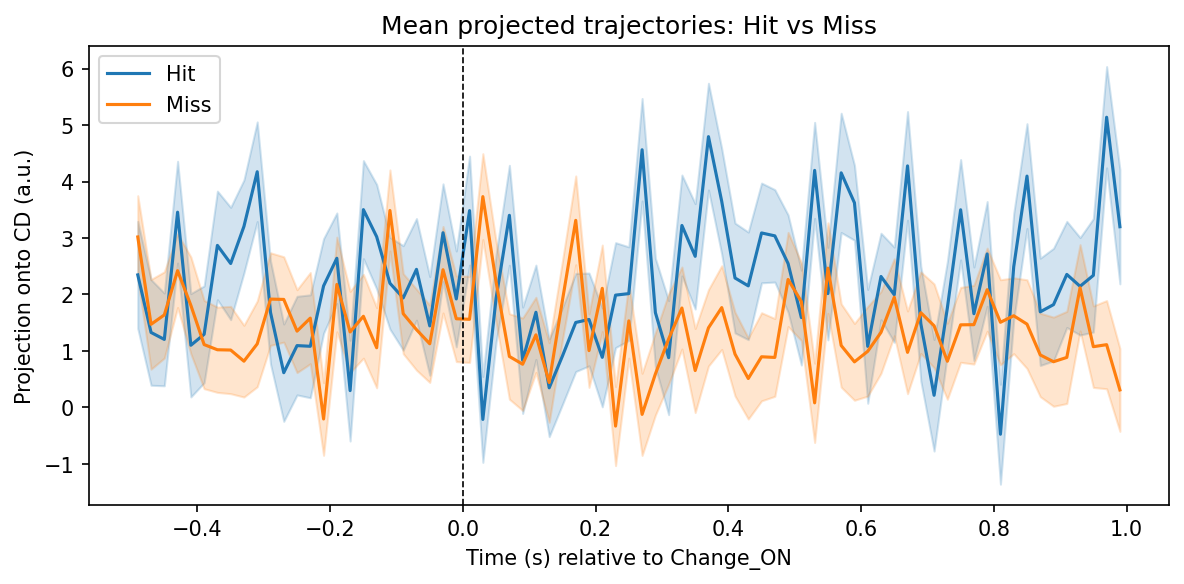

In [21]:
from IPython.display import display, Image
import io

# Plot Hit vs Miss using the helper and ensure it displays in the notebook
if 'proj' not in globals() or proj is None:
    print('No projections available; aborting plot')
else:
    bins = np.arange(window[0] + bin_size/2.0, window[1], bin_size)
    fig, ax = plot_projection_compare(proj, cond_hit, cond_miss, bins,
                                     labels=('Hit','Miss'), colors=('C0','C1'),
                                     title='Mean projected trajectories: Hit vs Miss')
    # Render figure to an in-memory PNG and display to ensure inline embedding
    try:
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        display(Image(data=buf.getvalue()))
        buf.close()
    except Exception:
        try:
            fig.canvas.draw()
            display(fig)
        except Exception:
            plt.show()

## 8) Compare coding direction: Hit vs False Alarm (baseline)

Run CD on Hit vs False Alarm (FA) trials and inspect baseline differences.

In [22]:
# Baseline_ON-based Hit vs FA (single canonical cell)
from src.align import compute_peth_for_session
peths_baseline = compute_peth_for_session(session, 'Baseline_ON', window=baseline_window, bin_size=bin_size)
# Build baseline-pop using the same cluster ordering `use_ids`
baseline_list = [peths_baseline[int(cid)]['trials_matrix'] for cid in use_ids]
baseline_pop = np.stack(baseline_list, axis=2)  # trials x baseline_bins x units
# collapse baseline bins -> features (trials x units)
X_baseline_all = baseline_pop.mean(axis=1)
# select Hit and FA trials and compute CD from baseline features
cond_fa = np.array([o == 'FA' or o == 'FalseAlarm' for o in trial_outcomes])
# Extract FA latency from the nested reactiontimes dict (preferred)
fa_latencies = np.array([np.nan if getattr(t, 'reactiontimes', None) is None else t.reactiontimes.get('FA', np.nan) for t in session.trials], dtype=float)
print('FA latencies finite:', np.isfinite(fa_latencies).sum())
# Compute CD using all FA and Hit trials (robust estimate)
sel = (cond_hit | cond_fa)
X_baseline = X_baseline_all[sel]          # selected trials x units
cond_sub = cond_hit[sel].astype(int)      # True for Hit, False for FA
if X_baseline.shape[0] < 2 or X_baseline.shape[1] == 0:
    print('Insufficient baseline data to compute CD')
else:
    from src.coding_direction import compute_cd_shrinkage
    cd = compute_cd_shrinkage(X_baseline, cond_sub, reg=1.0)  # units vector
    proj_baseline = np.tensordot(baseline_pop[sel], cd, axes=([2], [0]))  # trials_selected x baseline_bins
    # RT-filtered FA mask for visualization: FA latency > 3.0 s after Baseline_ON
    fa_long_mask = cond_fa & np.isfinite(fa_latencies) & (fa_latencies > 3.0)
    print('Total FA trials:', int(cond_fa.sum()), 'FA trials with RT>3s:', int(fa_long_mask.sum()))
    sel_vis = cond_hit | fa_long_mask
    if sel_vis.sum() > 0:
        proj_baseline_vis = np.tensordot(baseline_pop[sel_vis], cd, axes=([2], [0]))  # trials_vis x baseline_bins
        cond_sub_vis = cond_hit[sel_vis].astype(bool)
        print('proj_baseline_vis shape =', proj_baseline_vis.shape)

FA latencies finite: 129


IndexError: boolean index did not match indexed array along axis 0; size of axis is 569 but size of corresponding boolean axis is 568

In [10]:
# Plot Hit vs FA using the helper (proj_baseline corresponds to baseline-derived CD)
if 'proj_baseline' in globals():
    bins_baseline = np.arange(baseline_window[0] + bin_size/2.0, baseline_window[1], bin_size)
    fig, ax = plot_projection_compare(proj_baseline, cond_sub, ~cond_sub, bins_baseline,
                                     labels=('Hit','FA'), colors=('C0','C2'),
                                     title='Projection onto Baseline_CD (around Baseline_ON)')
    out_png_baseline = repo_root / 'notebooks' / 'demo_pipeline_projection_baseline.png'
    fig.savefig(str(out_png_baseline), dpi=150, bbox_inches='tight')
    print('Saved baseline projection to', out_png_baseline)
    plt.show()
else:
    print('proj_baseline not available; skipping Hit vs FA baseline plot')

Saved baseline projection to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\notebooks\demo_pipeline_projection_baseline.png


C:\Users\Ben\AppData\Local\Temp\ipykernel_5708\1718817310.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9) Save projection figure to `notebooks/demo_pipeline_projection.png`

Saves the last plot to a PNG for sharing.

Saved projection to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\notebooks\demo_pipeline_projection.png


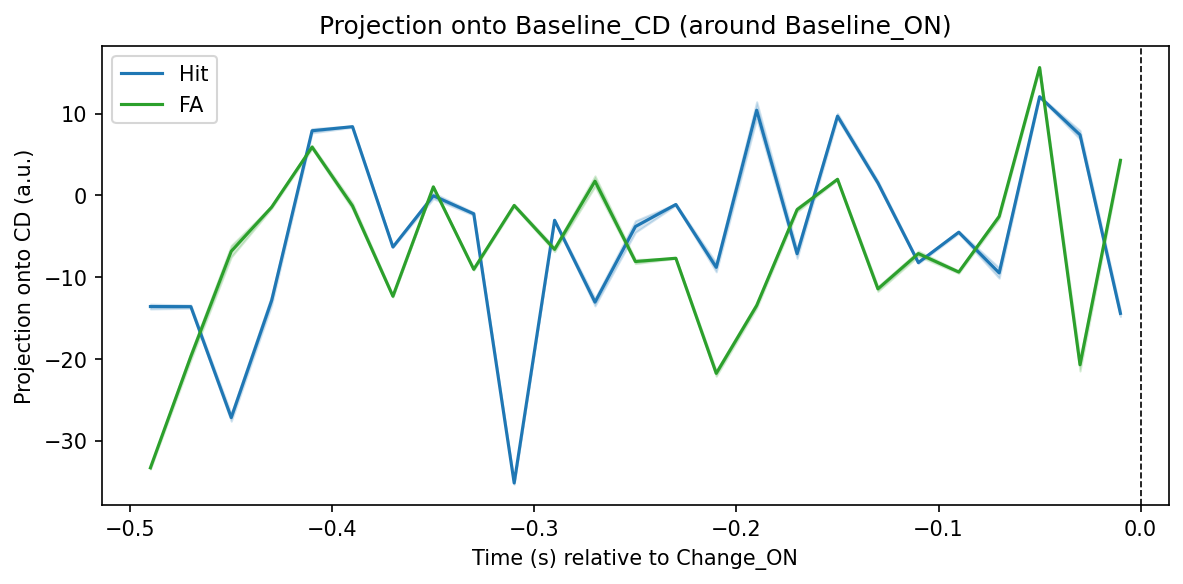

In [11]:
out_png = repo_root / 'notebooks' / 'demo_pipeline_projection.png'
plt.savefig(str(out_png), dpi=150, bbox_inches='tight')
print('Saved projection to', out_png)
# Optionally display saved file (works in interactive kernels)
try:
    from IPython.display import Image, display
    display(Image(str(out_png)))
except Exception:
    pass

---
Notes:
- The notebook uses a resilient loader to unpickle legacy session files.
- If you plan to run this in CI, pin `numpy` and `h5py` versions to avoid binary incompatibilities.
- To speed up permutation tests, reduce `n_permutations` or run them in parallel outside the notebook.

In [12]:
# Multi-group baseline projection + per-group stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from src.coding_direction import compute_cd_shrinkage

# Ensure baseline_pop and X_baseline_all exist (recompute minimally if not)
try:
    baseline_pop
    X_baseline_all
except NameError:
    from src.align import compute_peth_for_session
    print('Recomputing baseline PETHs (minimal)')
    # Recompute use_ids if not present
    try:
        use_ids
    except NameError:
        # build from Change_ON peths
        peths_tmp = compute_peth_for_session(session, 'Change_ON', window=window, bin_size=bin_size)
        use_ids = sorted([cid for cid, info in peths_tmp.items() if info['trials_matrix'].shape[0] > 0])
    peths_baseline = compute_peth_for_session(session, 'Baseline_ON', window=baseline_window, bin_size=bin_size)
    baseline_list = [peths_baseline[int(cid)]['trials_matrix'] for cid in use_ids]
    baseline_pop = np.stack(baseline_list, axis=2)  # trials x baseline_bins x units
    X_baseline_all = baseline_pop.mean(axis=1)

# Outcomes and masks
trial_outcomes = [getattr(t, 'trialoutcome', None) for t in session.trials]
cond_hit = np.array([o == 'Hit' for o in trial_outcomes])
cond_fa = np.array([o == 'FA' or o == 'FalseAlarm' for o in trial_outcomes])
cond_miss = np.array([o == 'Miss' for o in trial_outcomes])
cond_abort = np.array([isinstance(o, str) and ('abort' in o.lower()) for o in trial_outcomes])

# FA latency safe extraction from nested reactiontimes dict
fa_latencies = np.array([
    np.nan if getattr(t, 'reactiontimes', None) is None else t.reactiontimes.get('FA', np.nan)
    for t in session.trials
], dtype=float)

# FA long/short masks
fa_long = cond_fa & np.isfinite(fa_latencies) & (fa_latencies > 3.0)
fa_short = cond_fa & np.isfinite(fa_latencies) & (fa_latencies <= 3.0)

# Compute CD from Hit vs FA on collapsed baseline features if not already computed
try:
    cd
except NameError:
    sel_cd = cond_hit | cond_fa
    X_cd = X_baseline_all[sel_cd]
    y_cd = cond_hit[sel_cd].astype(int)
    if X_cd.shape[0] < 2:
        raise RuntimeError('Not enough trials to compute baseline CD (Hit vs FA)')
    cd = compute_cd_shrinkage(X_cd, y_cd, reg=1.0)

# Project Baseline_ON timecourse for all trials -> trials x baseline_bins
proj_baseline_all = np.tensordot(baseline_pop, cd, axes=([2], [0]))

# Build groups
groups = {
    'Hit': cond_hit,
    'FA>3s': fa_long,
    'FA<=3s': fa_short,
    'Abort': cond_abort,
    'Miss': cond_miss,
}
groups = {k: v for k, v in groups.items() if v.sum() > 0}
print('Groups and counts:')
for k, v in groups.items():
    print(' ', k, int(v.sum()))

# Plot groups using canonical outcome colors (from ephys_analysis notebook)
outcome_colors = {'FA': 'r', 'Hit': 'g', 'Miss': 'gray', 'abort': 'm'}
bins_baseline = np.arange(baseline_window[0] + bin_size / 2.0, baseline_window[1], bin_size)
fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, mask) in enumerate(groups.items()):
    if mask.sum() == 0:
        continue
    grp_proj = proj_baseline_all[mask]
    mean = grp_proj.mean(axis=0)
    sem = grp_proj.std(axis=0) / np.sqrt(max(1, grp_proj.shape[0]))
    # Map grouped label back to a base outcome color
    if label.startswith('FA'):
        base = 'FA'
    elif label.lower().startswith('abort'):
        base = 'abort'
    else:
        base = label
    color = outcome_colors.get(base, f'C{i % 10}')
    ax.fill_between(bins_baseline, mean - sem, mean + sem, color=color, alpha=0.15)
    ax.plot(bins_baseline, mean, label=f"{label} (n={int(mask.sum())})", color=color)

ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Time (s) relative to Baseline_ON')
ax.set_ylabel('Projection onto Baseline CD (a.u.)')
ax.legend(loc='upper right', fontsize='small')
ax.set_title('Baseline_CD projections: multiple behavioral outcomes')
fig.tight_layout()

# Save figure
out_png = repo_root / 'notebooks' / 'demo_pipeline_projection_baseline_groups.png'
fig.savefig(str(out_png), dpi=150, bbox_inches='tight')
print('Saved group baseline projection to', out_png)

# Keep references for interactive inspection
_plot_baseline_groups_fig = fig
_plot_baseline_groups_ax = ax

# ------------------------
# Per-group scalar statistics (avg across baseline bins -> one scalar per trial)
# ------------------------
scalar_proj = proj_baseline_all.mean(axis=1)  # trials
rows = []
for label, mask in groups.items():
    n = int(mask.sum())
    if n == 0:
        mean = np.nan
        sem = np.nan
    else:
        vals = scalar_proj[mask]
        mean = float(np.nanmean(vals))
        sem = float(np.nanstd(vals, ddof=0) / np.sqrt(max(1, n)))
    rows.append({'group': label, 'n': n, 'mean': mean, 'sem': sem})
stats_df = pd.DataFrame(rows).set_index('group')
print('\nPer-group scalar baseline projection summary:')
display(stats_df)

# Pairwise p-values (Welch's t-test) between groups
labels = list(groups.keys())
pvals = np.full((len(labels), len(labels)), np.nan)
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        if i >= j:
            continue
        mi = groups[li]
        mj = groups[lj]
        vi = scalar_proj[mi]
        vj = scalar_proj[mj]
        if vi.size < 2 or vj.size < 2:
            p = np.nan
        else:
            try:
                _, p = stats.ttest_ind(vi, vj, equal_var=False, nan_policy='omit')
            except Exception:
                p = np.nan
        pvals[i, j] = p
        pvals[j, i] = p
pvals_df = pd.DataFrame(pvals, index=labels, columns=labels)
print('\nPairwise p-values (Welch t-test):')
display(pvals_df)

# Save stats and p-values for reporting
stats_out = repo_root / 'notebooks' / 'demo_pipeline_baseline_group_stats.csv'
pvals_out = repo_root / 'notebooks' / 'demo_pipeline_baseline_group_pvalues.csv'
stats_df.to_csv(str(stats_out))
pvals_df.to_csv(str(pvals_out))
print('Saved stats to', stats_out)
print('Saved pairwise p-values to', pvals_out)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Ben\anaconda3\envs\copilot_ephys\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Ben\anaconda3\envs\copilot_ephys\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Ben\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Ben\anaconda3\envs\copilot_ephys\lib\site-packages\traitlets\config\application.py", line 1075, in launch_in

AttributeError: _ARRAY_API not found

Groups and counts:
  Hit 242
  FA>3s 256
  FA<=3s 112
  Abort 203
  Miss 103
Saved group baseline projection to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\notebooks\demo_pipeline_projection_baseline_groups.png

Per-group scalar baseline projection summary:


,n,mean,sem
group,,,
Hit,242,0.236326,0.232587
FA>3s,256,-4.245519,0.226993
FA<=3s,112,-5.075493,0.303511
Abort,203,-0.920487,0.336321
Miss,103,-0.940053,0.430879



Pairwise p-values (Welch t-test):


,Hit,FA>3s,FA<=3s,Abort,Miss
Hit,NaN,1.020371e-36,1.896401e-32,5.023892e-03,1.787394e-02
FA>3s,1.020371e-36,NaN,3.008827e-02,4.827313e-15,2.422544e-10
FA<=3s,1.896401e-32,3.008827e-02,NaN,9.471674e-18,4.059414e-13
Abort,5.023892e-03,4.827313e-15,9.471674e-18,NaN,9.715906e-01
Miss,1.787394e-02,2.422544e-10,4.059414e-13,9.715906e-01,NaN


Saved stats to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\notebooks\demo_pipeline_baseline_group_stats.csv
Saved pairwise p-values to E:\python_analysis\git_repos\vis_detect_analysis_Sep2025\notebooks\demo_pipeline_baseline_group_pvalues.csv
